# "THE PRICE IS RIGHT" Capstone Project:

In this module, we'll build a model that predicts how much something costs from a description, based on a scrape of Amazon data

## Order of play:

DAY 1: Data Curation

DAY 2: Data Pre-processing

DAY 3: Evaluation, Baselines, Traditional ML

DAY 4: Deep Learning and LLMs

DAY 5: Fine-tuning a Frontier Model

### DAY 1: Data Curation

Today we'll scrub our dataset and curate our data.

The dataset is here:
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

In [5]:
# Imports:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from pricer.items import Item
from pricer.parser import parse
load_dotenv(override= True)

True

In [6]:
# Logging in to Hugging Face:
hf_token = os.getenv('HF_TOKEN')
login(token = hf_token, add_to_git_credential= True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


### Loading in Dataset:

In the next cell, we load in the dataset from huggingface.

If this gives you an error like "trust_remote_code is no longer supported", then please run this command in a new cell: `!pip install --upgrade datasets==3.6.0` and then restart the Kernel, and try again.

In [7]:
dataset= load_dataset('McAuley-Lab/Amazon-Reviews-2023',
                      'raw_meta_Appliances',
                      split= 'full',
                      trust_remote_code= True)

README.md: 0.00B [00:00, ?B/s]

C:\Users\shail\anaconda3\envs\applied_llm_engineering\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shail\.cache\huggingface\hub\datasets--McAuley-Lab--Amazon-Reviews-2023. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Amazon-Reviews-2023.py: 0.00B [00:00, ?B/s]

raw/meta_categories/meta_Appliances.json(…):   0%|          | 0.00/285M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

In [8]:
print(f'Number of Appliances: {len(dataset)}')

Number of Appliances: 94327


In [11]:
# Investigating a Particular Datapoint:
dataset[10]

{'main_category': 'Tools & Home Improvement',
 'title': 'WP67003405 67003405 Door Pivot Block - Compatible Kenmore KitchenAid Maytag Whirlpool Refrigerator - Replaces AP6010352 8208254 PS11743531 - Quick DIY Repair Solution',
 'average_rating': 4.1,
 'rating_number': 4,
 'features': ['WP67003405 Pivot Block For Vernicle Mullion Strip On Door - A high-quality exact equivalent for part numbers AP6010352, 67003405, 1025322, 12698403, 67003194, 8208254, and PS11743531.',
  'Compatibility with major brands - WP67003405 Door Guide is compatible with Whirlpool, Amana, Dacor, Gaggenau, Hardwick, Jenn-Air, Kenmore, KitchenAid, and Maytag.',
  "Quick DIY repair - WP67003405 Refrigerator Door Guide Pivot Block Replacement will help if your appliance door doesn't open or close. Wear work gloves to protect your hands during the repair process.",
  'Attentive support - If you are uncertain about whether the block fits your refrigerator, we will help. We generally put forth a valiant effort to guaran

In [13]:
# Most Expensive Item:

max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint['price'])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"The Most Expensive Item is: {max_item['title']} and it Costs: {max_price:,.2f}")

  0%|          | 0/94327 [00:00<?, ?it/s]

The Most Expensive Item is: TurboChef BULLET Rapid Cook Electric Microwave Convection Oven and it Costs: 21,095.62


In [14]:
# Loading in Item Objects if they have a Price Range $1-$1000 and Enough Details:
items = [parse(datapoint, 'Appliances') for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"There are {len(items)} items from {len(dataset)} datapoints")

  0%|          | 0/94327 [00:00<?, ?it/s]

There are 35307 items from 94327 datapoints


In [15]:
items[0]

<WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003 = $8.99>

In [16]:
print(items[0].full)

Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003
['【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）', '【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud', '【 PART】, , , , , , , , , , , , ', '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure', '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund']
{"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color": "White", "Material Type": "Plastic", "Date First Available": "July 14, 2019", "Brand": "AMI PARTS", "Material": "Plastic", "Model Name": " Rack Roller and stud 

### Plotting Distribution of Description Lengths and Prices:

In [17]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

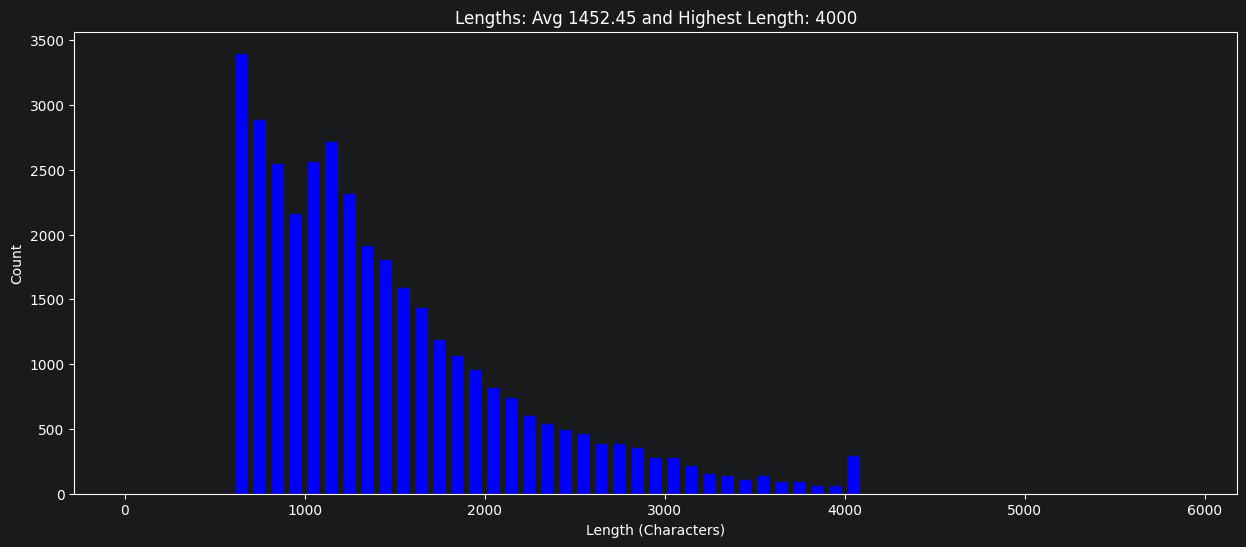

In [19]:
# Distribution of Description Lengths:
plt.figure(figsize= (15,6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):.2f} and Highest Length: {max(lengths)}")
plt.xlabel('Length (Characters)')
plt.ylabel('Count')
plt.hist(lengths, color= 'blue', bins= range(0, 6000, 100), rwidth= 0.7)
plt.show()

In [20]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

Polyester Dryer Vent Filters Replacement Part by Beaquicy Replacement for Better vent Indoor Dryer Vent Packs of 12
['✅【 AIR 】--- The polyester filters provide optimal air conditioning for your dryer and keep it away from polluted air. Because these parts will rate to trap fine lint and dust particles, protect your home from unwanted bacteria and other unfriendly dust particles and can be vacuumed clean or replaced when fully loaded with lint. so that the air in your room is cleaner than ever. While protecting your indoor quality, clothes can dry faster. It helps improve the indoor air quality.', '✅【HIGH-GRADE 】--- The package includes 12 x replacement polyester filters for bettervent.They are well-made from durable and high-grade polyester which can traps fine lint and dust particles, optimize the cleaning process and prolong lifetime. Each filter protects up to 5 dryer loads! For best results insert blue side facing towards dryer vent.', '✅【WIDE 】--- These polyester filters are desig